## •	Análisis del algoritmo de Grover mediante simulación cuántica

## Objetivo

Implementaremos el algoritmo de Grover utilizando Qiskit para analizar experimentalmente cómo evoluciona la probabilidad de encontrar un estado marcado.

Se estudiará:

- Implementación del algoritmo.
- Evolución de la probabilidad según el número de iteraciones.
- Comparación con una búsqueda clásica.
- Influencia del tamaño del espacio de búsqueda.

In [1021]:
import numpy as np          # Importaciones necesarias para el código
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram


In [1022]:
simulator = AerSimulator()    #iniciamos el simulador de Qiskit Aer

In [1023]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

# parametros de configuración de matplotlib para mejorar la estética de las gráficas
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


# Problema de búsqueda

Supongamos que tenemos una base de datos con dieciseis elementos.

Nuestro objetivo consiste en encontrar el número **18**.

En un computador clásico, la búsqueda más simple consiste en revisar cada elemento uno por uno hasta encontrar el valor deseado.

Posteriormente resolveremos exactamente el mismo problema utilizando el algoritmo de Grover y compararemos ambos métodos.

In [1024]:
database = [12, 7, 25, 3, 18, 9, 30, 15, 22, 5, 11, 14, 19, 2, 27, 6]
np.random.shuffle(database)  # Mezclamos la base de datos para simular un escenario real
target = 18

print("Base de datos:")
print(database)

print("\nNúmero buscado:", target)

Base de datos:
[22, 14, 27, 2, 9, 25, 12, 5, 7, 6, 11, 3, 19, 30, 18, 15]

Número buscado: 18


# Búsqueda clásica

Primero implementaremos una búsqueda lineal.

Este algoritmo revisa los elementos de la lista uno por uno hasta encontrar el valor buscado.

Además de encontrar el índice, contaremos cuántas comparaciones fueron necesarias.

In [1025]:
def metodo_clasico(database, target):     # Funcion que implementa el método clásico de búsqueda lineal
    comparaciones = 0
    for index, value in enumerate(database):
        comparaciones += 1
        if value == target:
            return index, comparaciones
    return None, comparaciones

index, comparaciones = metodo_clasico(database, target)

print(f"Índice encontrado: {index}")
print(f"Comparaciones realizadas: {comparaciones}")

Índice encontrado: 14
Comparaciones realizadas: 15


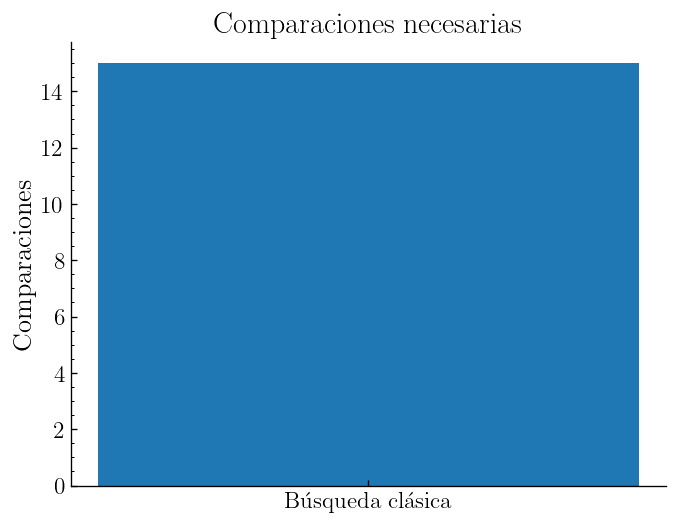

In [1026]:
plt.bar(["Búsqueda clásica"], [comparaciones])

plt.ylabel("Comparaciones")

plt.title("Comparaciones necesarias")
plt.show()

# Representación del problema en un computador cuántico

Un computador cuántico no almacena directamente los valores de la base de datos.

En su lugar, representa cada **posición** mediante un estado cuántico.

Como nuestra base de datos contiene dieciséis elementos, necesitamos cuatro qubits para representar todos los índices posibles.

| Índice | Estado |
|--------|--------|
|0|0000|
|1|0001|
|2|0010|
|3|0011|
|4|0100|
|5|0101|
|6|0110|
|7|0111|
|8|1000|
|9|1001|
|10|1010|
|11|1011|
|12|1100|
|13|1101|
|14|1110|
|15|1111|

El número buscado es **18**, que se encuentra en la posición correspondiente dentro de la base de datos.

Por lo tanto, el algoritmo de Grover buscará el estado correspondiente a esa posición, representado en binario de 4 bits.

El 18 está en la posición 14, que corresponde al estado |1110>
Número de iteraciones óptimo: 3


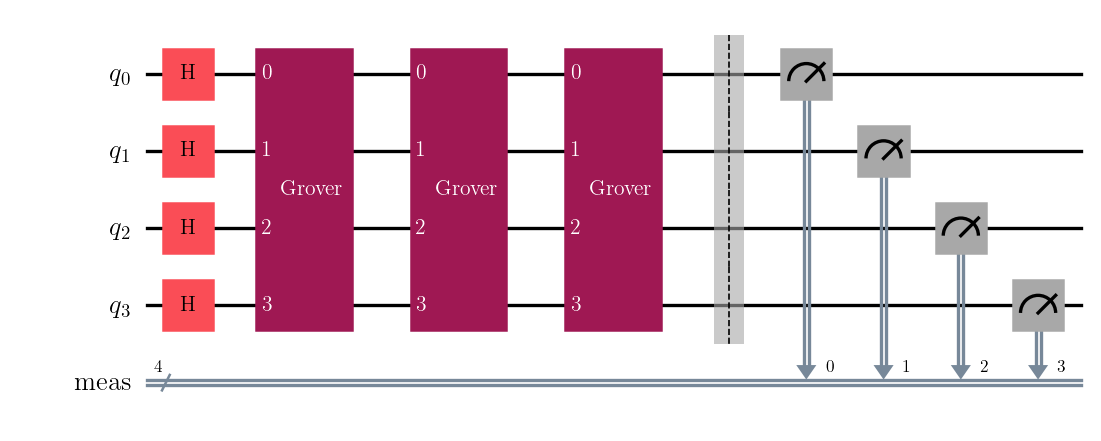

In [1027]:

def oraculo_grover(n, estado_marcado): #Funcion principal que implementa el oráculo de Grover, marca el estado buscado invirtiendo su fase
    qc = QuantumCircuit(n, name="Oráculo")

    # Qiskit numera los qubits en orden little-endian (qubit 0 = bit menos significativo),
    # por eso invertimos la cadena para que coincida con la notación que escribimos (|100>)
    estado_marcado = estado_marcado[::-1]
    ceros = [i for i, bit in enumerate(estado_marcado) if bit == '0']

    if ceros:
        qc.x(ceros)         
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)   # Se aplican compuertas cuanticas controladas para invertir la fase del estado marcado
    qc.h(n - 1)
    if ceros:
        qc.x(ceros)          

    return qc


def difusor(n):   #Funcion principal que implementa el difusor de Grover, que realiza la inversión sobre la media de los estados y amplifica la probabilidad del estado marcado
    qc = QuantumCircuit(n, name="Difusor")

    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))

    return qc

def operador_grover(n, estado_marcado):
    """Combina oráculo + difusor en UNA sola puerta llamada 'Grover'."""
    qc = QuantumCircuit(n, name="Grover")
    qc.append(oraculo_grover(n, estado_marcado).to_gate(), range(n))
    qc.append(difusor(n).to_gate(), range(n))
    return qc.to_gate(label="Grover")


# Parámetros del problema: 4 qubits, buscamos el estado donde está el 18)
n_qubits = int(np.log2(len(database)))  # número de qubits necesarios para representar la base de datos
estado_buscado = format(index, f'0{n_qubits}b')  # convertimos el índice a binario con n_qubits bits
print(f"El {target} está en la posición {index}, que corresponde al estado |{estado_buscado}>")
# Número óptimo de iteraciones de Grover: ~ (pi/4) * sqrt(N)
n_iteraciones = int(np.floor(np.pi / 4 * np.sqrt(2**n_qubits))) # Este numero de iteraciones es el que maximiza la probabilidad de encontrar el estado marcado
print(f"Número de iteraciones óptimo: {n_iteraciones}")

# Construimos el circuito completo
qc_grover = QuantumCircuit(n_qubits)
qc_grover.h(range(n_qubits))  # superposición inicial

for _ in range(n_iteraciones):
    qc_grover.append(operador_grover(n_qubits, estado_buscado), range(n_qubits))
    
qc_grover.measure_all()
qc_grover.draw('mpl')


Despues de 3 iteraciones, medimos el sistema 1024 veces para obtener una distribución de probabilidad.

In [1028]:

qc_transpiled = transpile(qc_grover, simulator)
result = simulator.run(qc_transpiled, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)


Resultados: {'0010': 1, '0101': 2, '0001': 2, '0011': 1, '0111': 3, '1111': 1, '1101': 3, '1010': 4, '1011': 6, '0000': 2, '0110': 2, '1100': 1, '0100': 3, '1000': 5, '1110': 988}


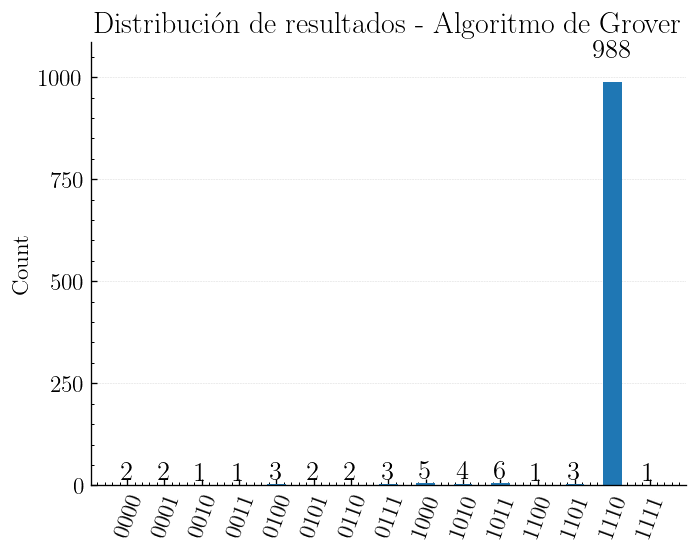

In [1029]:

fig = plot_histogram(counts, title="Distribución de resultados - Algoritmo de Grover")
fig

# Comparación clásica vs cuántica

La búsqueda clásica necesitó revisar los elementos uno por uno (en el peor caso, hasta 16 comparaciones).

El algoritmo de Grover, en cambio, encuentra el estado marcado con muy alta probabilidad en solo un par de iteraciones (del orden de $\sqrt{N}$), en lugar de $N$ comparaciones.


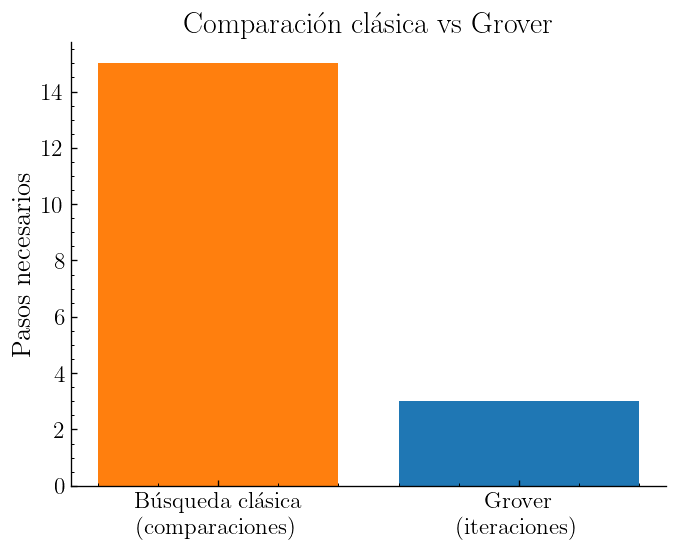

Probabilidad de medir el estado buscado |1110>: 96.48%


In [1030]:
prob_exito = counts.get(estado_buscado, 0) / 1024

plt.bar(["Búsqueda clásica\n(comparaciones)", "Grover\n(iteraciones)"],
        [comparaciones, n_iteraciones],
        color=["tab:orange", "tab:blue"])
plt.ylabel("Pasos necesarios")
plt.title("Comparación clásica vs Grover")
plt.show()

print(f"Probabilidad de medir el estado buscado |{estado_buscado}>: {prob_exito:.2%}")
